In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data = pd.read_csv("marketing_data.csv")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [4]:
data.columns = data.columns.str.strip()

In [5]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [8]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [9]:
data['Income'].head(10)

0    $84,835.00 
1    $57,091.00 
2    $67,267.00 
3    $32,474.00 
4    $21,474.00 
5    $71,691.00 
6    $63,564.00 
7    $44,931.00 
8    $65,324.00 
9    $65,324.00 
Name: Income, dtype: object

In [10]:
data['Income'].dtype

dtype('O')

In [11]:
data["Income"] = (data["Income"].str.replace("$", "", regex = False)
                 .str.replace(",", "", regex = False)
                 .astype(float))

In [12]:
data['Income'].head(10)

0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
5    71691.0
6    63564.0
7    44931.0
8    65324.0
9    65324.0
Name: Income, dtype: float64

In [13]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [15]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"])

In [16]:
data["Dt_Customer"].dtype

dtype('<M8[ns]')

In [17]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [18]:
(data["Education"].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
(data["Marital_Status"].value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

In [20]:
data["Education"] = data["Education"].replace({"2n Cycle": "Master", "Basic": "Undergraduate"})
data["Marital_Status"] = data["Marital_Status"].replace({"Together": "Married", "Divorced": "Single", 
"Widow": "Single", "Alone": "Single", "YOLO": "Single", "Absurd": "Single"})
print(data["Education"].value_counts())
print(data["Marital_Status"].value_counts())

Education
Graduation       1127
Master            573
PhD               486
Undergraduate      54
Name: count, dtype: int64
Marital_Status
Married    1444
Single      796
Name: count, dtype: int64


In [21]:
group_mean = data.groupby(["Education", "Marital_Status"])["Income"].transform("mean")

data["Income"] = data["Income"].fillna(group_mean)

In [22]:
data["Income"].isnull().sum()

np.int64(0)

In [23]:
data["Spending"] = (
    data["MntWines"]
    + data["MntFruits"]
    + data["MntMeatProducts"]
    + data["MntFishProducts"]
    + data["MntSweetProducts"]
    + data["MntGoldProds"]
)

In [25]:
data["Spending"].head(10)

0    1190
1     577
2     251
3      11
4      91
5    1192
6    1215
7      96
8     544
9     544
Name: Spending, dtype: int64

In [26]:
data["Children_count"] = data["Kidhome"] + data["Teenhome"]

In [27]:
data["Children_count"].head(10)

0    0
1    0
2    1
3    2
4    1
5    0
6    0
7    1
8    1
9    1
Name: Children_count, dtype: int64

In [28]:
data["has_children"] = (data["Children_count"] > 0).astype(int)

In [29]:
data["has_children"].head(10)

0    0
1    0
2    1
3    1
4    1
5    0
6    0
7    1
8    1
9    1
Name: has_children, dtype: int64

In [30]:
data["total_purchases"] = (
    data["NumDealsPurchases"]
    + data["NumWebPurchases"]
    + data["NumCatalogPurchases"]
    + data["NumStorePurchases"]
)

In [31]:
data["total_purchases"].head(10)

0    15
1    18
2    11
3     4
4     8
5    17
6    28
7     7
8    20
9    20
Name: total_purchases, dtype: int64

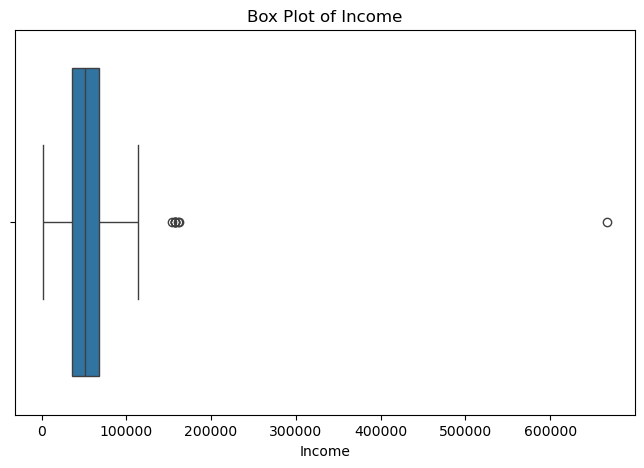

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Income"])
plt.title("Box Plot of Income")
plt.xlabel("Income")
plt.show()

In [35]:
data["Income"].describe()

count      2240.000000
mean      52252.797256
std       25038.801365
min        1730.000000
25%       35538.750000
50%       51533.000000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

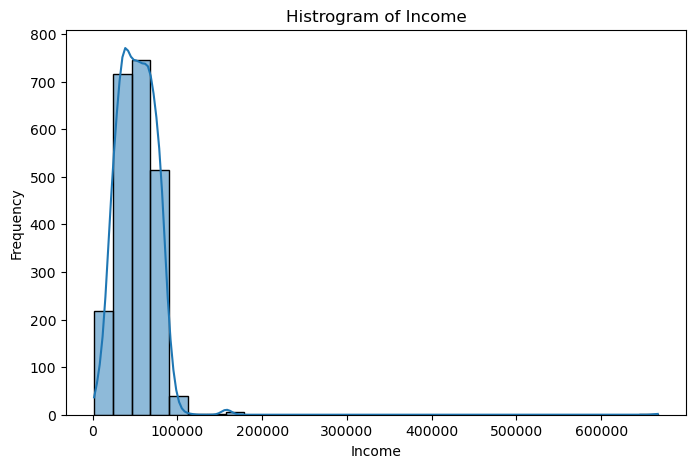

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Income"], bins = 30, kde = True)
plt.title("Histrogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

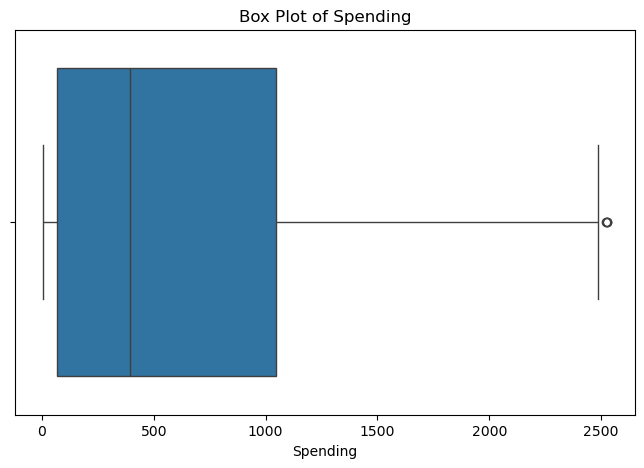

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Spending"])
plt.title("Box Plot of Spending")
plt.xlabel("Spending")
plt.show()

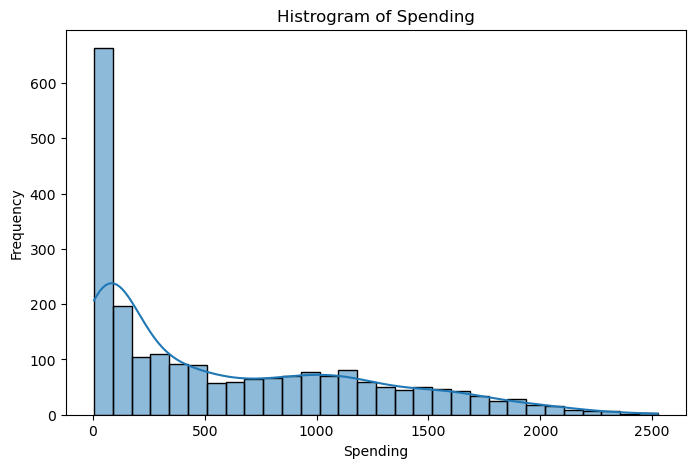

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Spending"], bins = 30, kde = True)
plt.title("Histrogram of Spending")
plt.xlabel("Spending")
plt.ylabel("Frequency")
plt.show()

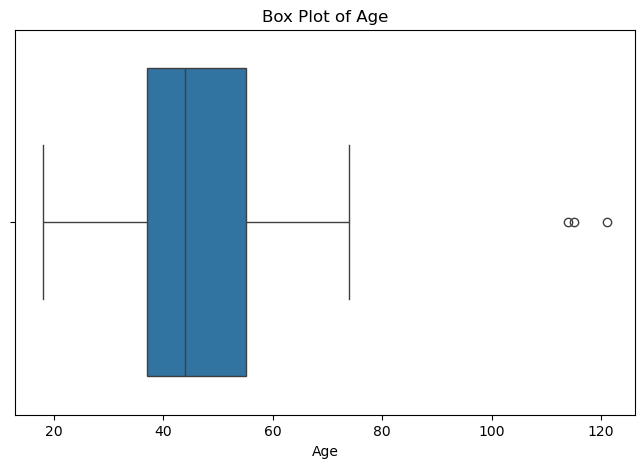

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

In [41]:
data["Age"] = 2014 - data["Year_Birth"]

In [42]:
data["Age"].head(10)

0    44
1    53
2    56
3    47
4    25
5    56
6    60
7    47
8    60
9    60
Name: Age, dtype: int64

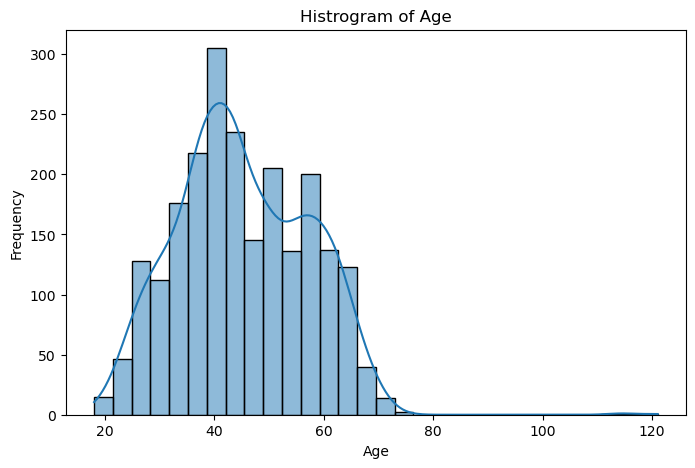

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Age"], bins = 30, kde = True)
plt.title("Histrogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

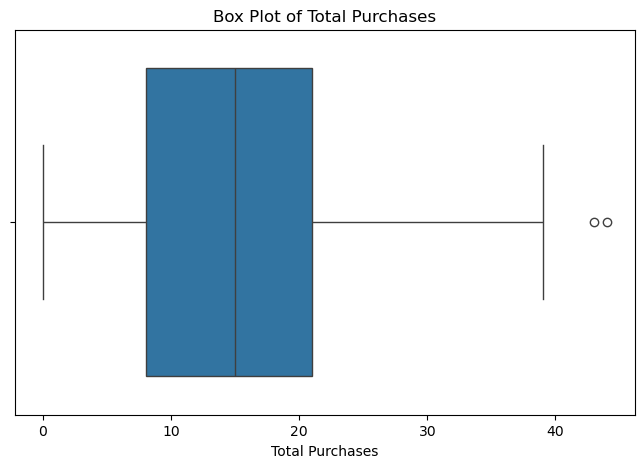

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["total_purchases"])
plt.title("Box Plot of Total Purchases")
plt.xlabel("Total Purchases")
plt.show()

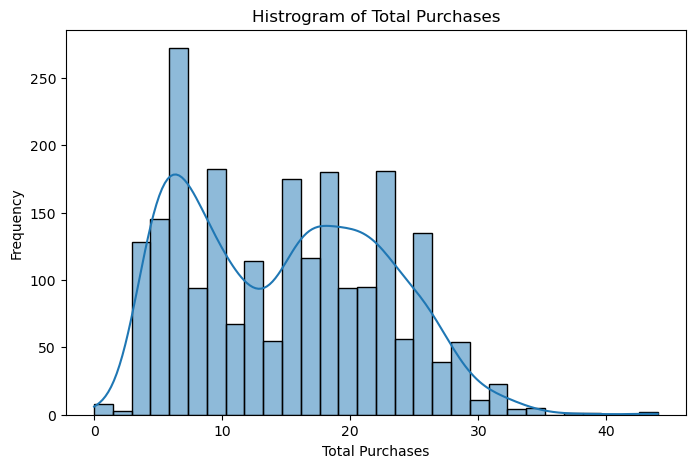

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(data["total_purchases"], bins = 30, kde = True)
plt.title("Histrogram of Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

In [48]:
columns = ["Income", "Spending", "Age", "total_purchases"]

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    print(col)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print()

Income
Lower Limit: -13587.75
Upper Limit: 117416.25

Spending
Lower Limit: -1396.375
Upper Limit: 2510.625

Age
Lower Limit: 10.0
Upper Limit: 82.0

total_purchases
Lower Limit: -11.5
Upper Limit: 40.5



In [50]:
columns = ["Income", "Spending", "Age", "total_purchases"]

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower = lower_limit, upper = upper_limit)

print("Outlier capping completed.")

Outlier capping completed.


In [51]:
for col in columns:
    print(col)
    print("Minimum:", data[col].min())
    print("Maximum:", data[col].max())
    print()

Income
Minimum: 1730.0
Maximum: 117416.25

Spending
Minimum: 5.0
Maximum: 2510.625

Age
Minimum: 18
Maximum: 82

total_purchases
Minimum: 0.0
Maximum: 40.5



In [53]:
education_order = {"Undergraduate": 1, "Graduation": 2, "Master": 3, "PhD": 4}

data["Education_encoded"] = data["Education"].map(education_order)
data[["Education", "Education_encoded"]].head(10)

,Education,Education_encoded
0,Graduation,2
1,Graduation,2
2,Graduation,2
3,Graduation,2
4,Graduation,2
5,PhD,4
6,Master,3
7,Graduation,2
8,PhD,4
9,PhD,4


In [56]:
data = pd.get_dummies(data, columns = ["Marital_Status"], drop_first = True)

data.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Response,Complain,Country,Spending,Children_count,has_children,total_purchases,Age,Education_encoded,Marital_Status_Single
0,1826,1970,Graduation,84835.0,0,0,2014-06-16,0,189,104,...,1,0,SP,1190.0,0,0,15.0,44,2,True
1,1,1961,Graduation,57091.0,0,0,2014-06-15,0,464,5,...,1,0,CA,577.0,0,0,18.0,53,2,True
2,10476,1958,Graduation,67267.0,0,1,2014-05-13,0,134,11,...,0,0,US,251.0,1,1,11.0,56,2,False
3,1386,1967,Graduation,32474.0,1,1,2014-05-11,0,10,0,...,0,0,AUS,11.0,2,1,4.0,47,2,False
4,5371,1989,Graduation,21474.0,1,0,2014-04-08,0,6,16,...,1,0,SP,91.0,1,1,8.0,25,2,True


In [57]:
data = pd.get_dummies(data, columns = ["Country"], drop_first = True)

data.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Age,Education_encoded,Marital_Status_Single,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,1826,1970,Graduation,84835.0,0,0,2014-06-16,0,189,104,...,44,2,True,False,False,False,False,False,True,False
1,1,1961,Graduation,57091.0,0,0,2014-06-15,0,464,5,...,53,2,True,True,False,False,False,False,False,False
2,10476,1958,Graduation,67267.0,0,1,2014-05-13,0,134,11,...,56,2,False,False,False,False,False,False,False,True
3,1386,1967,Graduation,32474.0,1,1,2014-05-11,0,10,0,...,47,2,False,False,False,False,False,False,False,False
4,5371,1989,Graduation,21474.0,1,0,2014-04-08,0,6,16,...,25,2,True,False,False,False,False,False,True,False


In [58]:
var_cor = ["Income", "Spending", "Age", "total_purchases", "Children_count", "Recency"]

new_data = data[var_cor]
corr_matrix = new_data.corr()
corr_matrix

,Income,Spending,Age,total_purchases,Children_count,Recency
Income,1.000000,0.803721,0.204338,0.679120,-0.345197,0.005122
Spending,0.803721,1.000000,0.113313,0.754236,-0.498898,0.020445
Age,0.204338,0.113313,1.000000,0.175382,0.093232,0.020039
total_purchases,0.679120,0.754236,0.175382,1.000000,-0.245846,0.005981
Children_count,-0.345197,-0.498898,0.093232,-0.245846,1.000000,0.018053
Recency,0.005122,0.020445,0.020039,0.005981,0.018053,1.000000


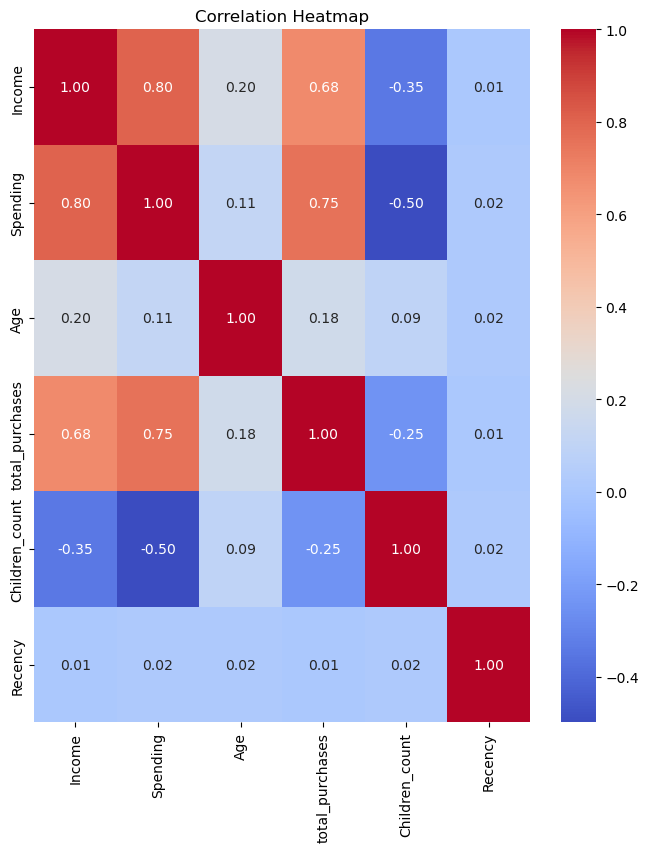

In [59]:
plt.figure(figsize = (8, 9))

sns.heatmap(corr_matrix, annot = True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [61]:
from scipy import stats

group_accepted = data[data["AcceptedCmp5"] == 1] ["Spending"]
group_not_accepted = data[data["AcceptedCmp5"] == 0] ["Spending"]

t_stat, p_value = stats.ttest_ind(group_accepted, group_not_accepted, equal_var = False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 31.296634364870634
P-value: 2.118931988675651e-80


In [62]:
prod_data = data[["MntWines", 
                  "MntFruits", 
                  "MntMeatProducts", 
                  "MntFishProducts", 
                  "MntSweetProducts", 
                  "MntGoldProds"]].sum()

prod_data

MntWines            680816
MntFruits            58917
MntMeatProducts     373968
MntFishProducts      84057
MntSweetProducts     60621
MntGoldProds         98609
dtype: int64

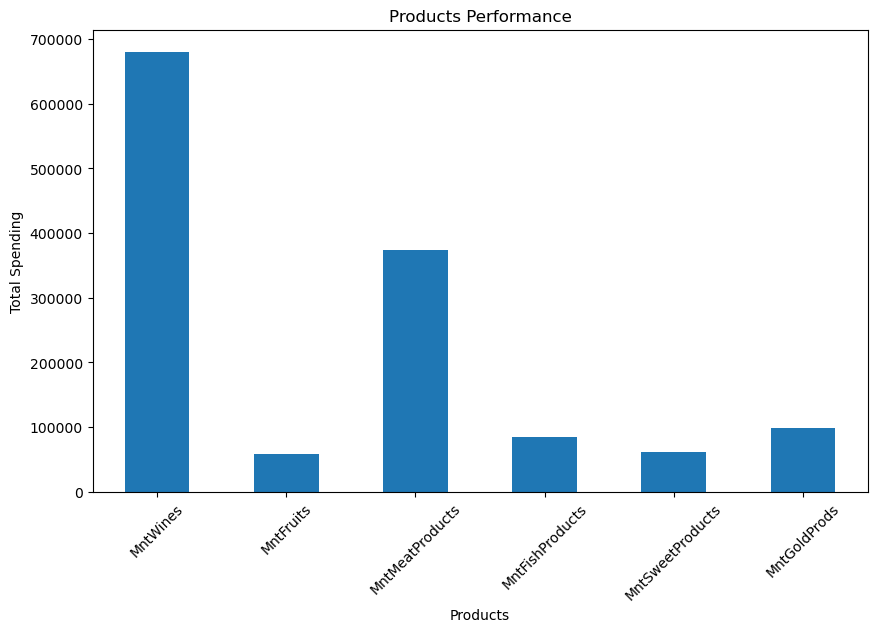

In [63]:
plt.figure(figsize = (10, 6))

prod_data.plot(kind = "bar")

plt.title("Products Performance")
plt.xlabel("Products")
plt.ylabel("Total Spending")
plt.xticks(rotation = 45)
plt.show()

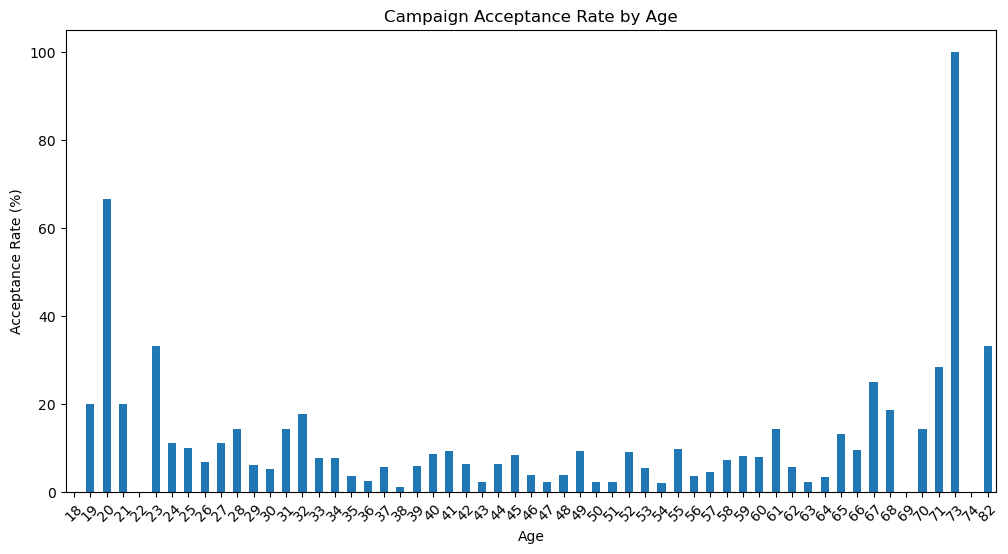

In [66]:
age_acceptance = data.groupby("Age")["AcceptedCmp5"].mean() * 100

plt.figure(figsize = (12, 6))

age_acceptance.plot(kind = "bar")

plt.title("Campaign Acceptance Rate by Age")
plt.xlabel("Age")
plt.ylabel("Acceptance Rate (%)")
plt.xticks(rotation = 45)
plt.show()

In [67]:
country_cols = [col for col in data.columns if col.startswith("Country_")]

country_acceptance = {}

for col in country_cols:
    country = col.replace("Country_", "")
    country_acceptance[country] = (
        data.loc[data[col] == True, "AcceptedCmp5"].sum()
    )

country_acceptance = pd.Series(country_acceptance)

country_acceptance

CA     21
GER     8
IND     6
ME      0
SA     21
SP     89
US      5
dtype: int64

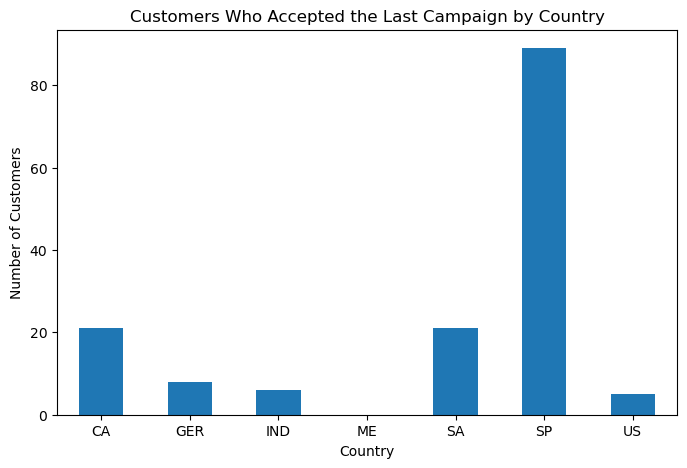

In [68]:
plt.figure(figsize=(8, 5))

country_acceptance.plot(kind="bar")

plt.title("Customers Who Accepted the Last Campaign by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

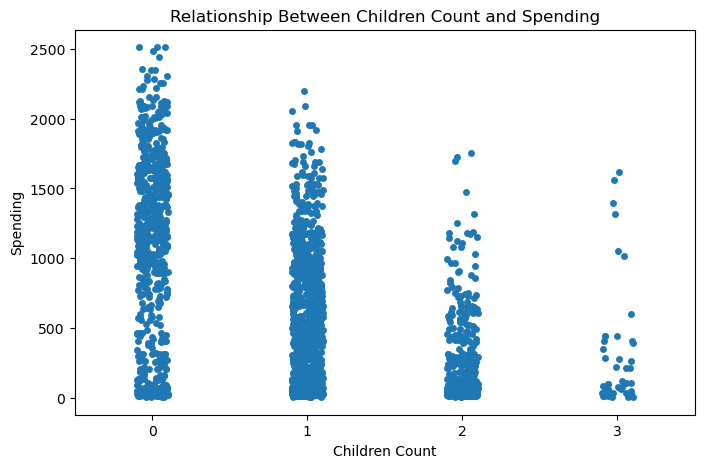

In [69]:
plt.figure(figsize=(8, 5))

sns.stripplot(
    data=data,
    x="Children_count",
    y="Spending"
)

plt.title("Relationship Between Children Count and Spending")
plt.xlabel("Children Count")
plt.ylabel("Spending")
plt.show()

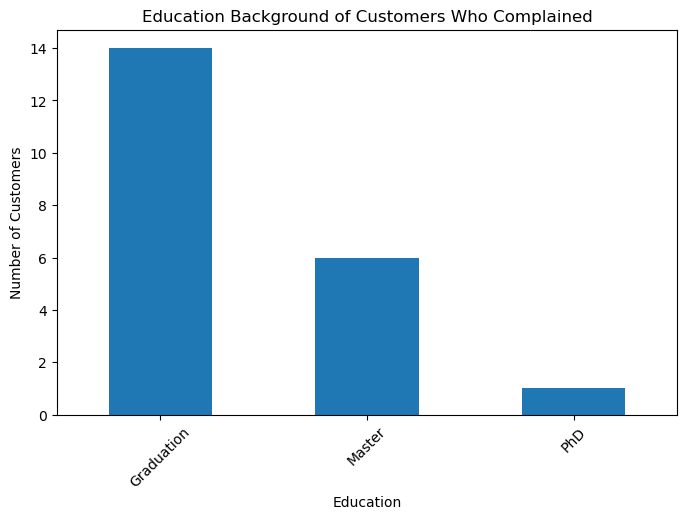

In [70]:
complain_education = data[data["Complain"] == 1]["Education"].value_counts()

plt.figure(figsize=(8, 5))

complain_education.plot(kind="bar")

plt.title("Education Background of Customers Who Complained")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

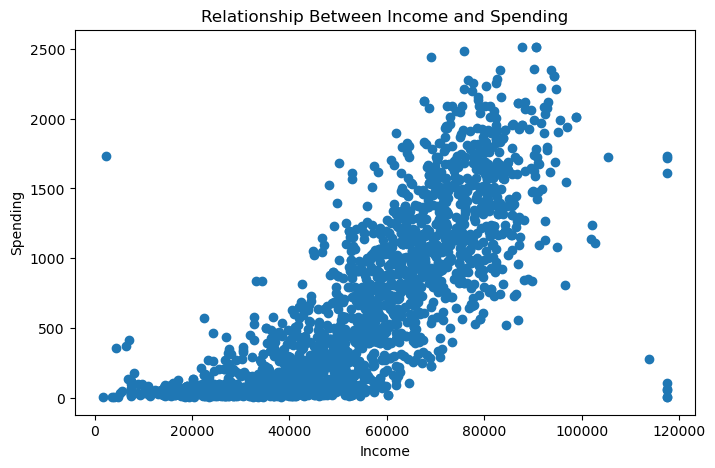

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(data["Income"], data["Spending"])

plt.title("Relationship Between Income and Spending")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()